# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

We want to limit the complexity of the model, so we add this penalty to MSE so that we "charge" the model for "buying" more and more coefficients. This way, the model minimizes the amount of coefficients it uses.

2. How does regularization provide a way of exploring the bias-variance trade-off?


A higher penalty minimizes the variance in the model by reducing coefficients (making the model less over-fitted), at the expense of introducing more bias. Regularization thus allows us to choose how much bias vs how much variance we want.

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

LASSO minimizes $MSE(b) + \alpha(|b_1| + |b_2|+...+|b_L|)$, while ridge minimizes $MSE(b) + \alpha(b_1^2 + b_2^2+...+b_L^2)$. LASSO sends coefficients to 0 as alpha increases (removing variables for a model and selecting a spec for you). Ridge, meanwhile, smoothly shrinks all coeffs to something approaching zero but never removes a variable completely. LASSO also results in corners as models approach 0, while ridge is smooth at 0.

4. How do we typically scale variables for use in regularized regression? Why?

We usually z-score normalize our numeric variables (but not our dummies/categorical variables). This is because the penalty is focused on the size of the coefficient, beta, so variables with larger scales would be penalized more if we did not normalize.

5. How is the penalty $\alpha$ typically selected?

$\alpha$ is typically selected with cross-validation. We pick a grid of $\alpha$ values, use k-fCV for each (picking mean/median value of MSE($\beta$) for that $\alpha$), and then we pick the $\alpha$ that has the least mean/median MSE($\beta$).

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

We don't include the penalty term. The goal of cross-validation is to see how the model would perform on unknown data, and unknown data would not have a penalty term included when calculating MSEs. The penalty term is included when we train the fold models, and removed when we benchmark them.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.

In [1]:
# Get data
! git clone https://github.com/ds4e/get_data
%run ./get_data/get_data.py

# Import libraries
from sklearn.linear_model import LassoCV, lasso_path, LinearRegression, Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

Cloning into 'get_data'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 121 (delta 43), reused 32 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (121/121), 1.76 MiB | 6.71 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Download complete
Extracting data files...
Data extracted


In [2]:
# Load data
df = pd.read_csv('./data/cars_hw.csv', encoding = "utf-8").rename(columns=lambda c: c.strip())
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [3]:
# Make age
df['Age'] = np.max(df['Make_Year']) - df['Make_Year']

In [4]:
# Take Mileage_Run and Age, and (a) use PolynomialFeatures to create a third degree expansion
vars_to_expand = ['Mileage_Run', 'Age']
expander = PolynomialFeatures(degree=3, include_bias=False)
X_poly = expander.fit_transform(df[vars_to_expand])
poly_names = expander.get_feature_names_out(vars_to_expand)

# put expanded variables into a DataFrame
X_poly_df = pd.DataFrame(X_poly, columns=poly_names, index=df.index)

# (b) z-score normalize
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_df)
X_poly_scaled_df = pd.DataFrame(X_poly_scaled,columns=poly_names,index=df.index
)

df = pd.concat([df.drop(columns=vars_to_expand), X_poly_scaled_df],axis=1
)
df.head(2)

,Unnamed: 0,Make,Make_Year,Color,Body_Type,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Mileage_Run,Age,Mileage_Run^2,Mileage_Run Age,Age^2,Mileage_Run^3,Mileage_Run^2 Age,Mileage_Run Age^2,Age^3
0,1,Volkswagen,2017,silver,sedan,1st,5,diesel,7-Speed,Automatic,657000,0.124692,-0.013092,-0.137673,-0.116749,-0.254727,-0.294615,-0.271881,-0.306552,-0.381579
1,2,Hyundai,2016,red,crossover,1st,5,petrol,5-Speed,Manual,682000,-0.872334,0.341858,-0.791316,-0.565613,0.082563,-0.661216,-0.662907,-0.480726,-0.117623


2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

In [5]:
# Outcome variable
y = df['Price']  # assuming price is y

# Run linear regression
lr = LinearRegression()
lr.fit(X_poly_scaled_df, y)

# Put coefficients in a readable table
coef_table = pd.DataFrame({
    'feature': X_poly_scaled_df.columns,
    'coefficient': lr.coef_
})

coef_table

,feature,coefficient
0,Mileage_Run,458071.119627
1,Age,-136698.072100
2,Mileage_Run^2,-91643.120024
3,Mileage_Run Age,-898405.751356
4,Age^2,113603.822348
5,Mileage_Run^3,-65144.896599
6,Mileage_Run^2 Age,229021.676556
7,Mileage_Run Age^2,368955.713359
8,Age^3,-84038.066146


The interaction between age and mileage_run has a negative sign.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)

In [6]:
alpha_grid = np.logspace(1,3,20)
model = LassoCV(cv=20,
                alphas=alpha_grid)
model = model.fit(X_poly_scaled_df, y)

index_star = np.argmin( np.mean(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 20079176862.5625, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 97387566888.89062, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 148080972789.21875, tolerance: 12678950600.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Object

4. Plot the cross-validated MSE by $\alpha$.

Optimal cost hyperparameter: 784.7599703514607


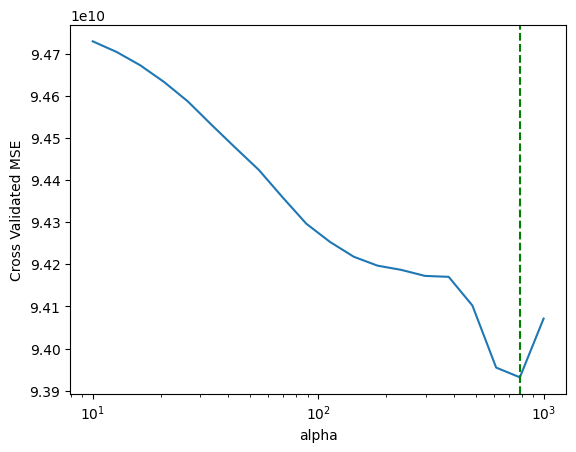

In [7]:
sns.lineplot( x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

5. Plot the coefficient paths by $\alpha$.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 141463082612.375, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 541616931672.25, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 571380445024.625, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective 

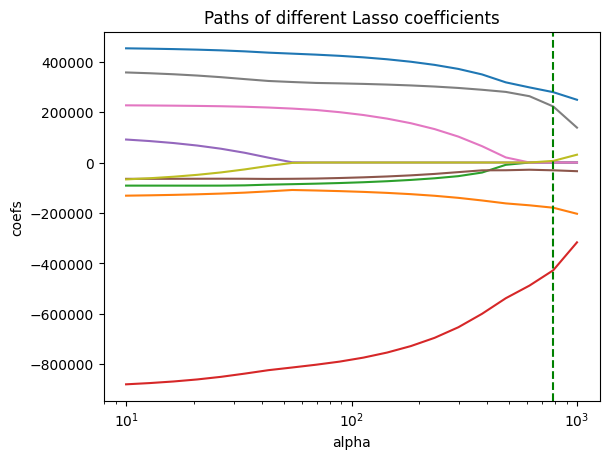

In [8]:
results = lasso_path(X_poly_scaled, y, alphas=alpha_grid)

alphas_path = results[0]
coefs = results[1]
extra_info = results[2]

for coef in coefs:
    plt.plot(alphas_path, coef)
plt.axvline(x=model.alpha_, color='green', linestyle='--')
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefs")
plt.title("Paths of different Lasso coefficients")
plt.show()

6. Which features are actually selected? What proportion are set equal to zero?

In [9]:
coef_table = pd.DataFrame({
    'feature': X_poly_scaled_df.columns,
    'LASSO coefficient': model.coef_,
})

coef_table

,feature,LASSO coefficient
0,Mileage_Run,279901.144475
1,Age,-178627.649418
2,Mileage_Run^2,-0.000000
3,Mileage_Run Age,-430522.371167
4,Age^2,-0.000000
5,Mileage_Run^3,-30772.352392
6,Mileage_Run^2 Age,0.000000
7,Mileage_Run Age^2,224381.027339
8,Age^3,5666.626835


The LASSO selects Mileage_Run, Age, Mileage_Run x Age, Mileage_Run^3, Mileage_Run x Age^2, and Age ^3. It excludes 3/9 coefficients.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [10]:
coef_table = pd.DataFrame({
    'feature': X_poly_scaled_df.columns,
    'LASSO coefficient': model.coef_,
    'linear regression coefficient': lr.coef_
})

coef_table

,feature,LASSO coefficient,linear regression coefficient
0,Mileage_Run,279901.144475,458071.119627
1,Age,-178627.649418,-136698.072100
2,Mileage_Run^2,-0.000000,-91643.120024
3,Mileage_Run Age,-430522.371167,-898405.751356
4,Age^2,-0.000000,113603.822348
5,Mileage_Run^3,-30772.352392,-65144.896599
6,Mileage_Run^2 Age,0.000000,229021.676556
7,Mileage_Run Age^2,224381.027339,368955.713359
8,Age^3,5666.626835,-84038.066146


No coefficients apart from the Age^3 one change sign. Coefficients generally decreased in magnitude compared to the linear regresison ones, which is what we'd expect from a LASSO.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.

In [11]:
# Import data
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv', encoding = "utf-8").rename(columns=lambda c: c.strip())
df.head(2)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1


In [12]:
# Expand vars to 3rd degree
vars_to_expand = ['age', 'ejection_fraction', 'serum_creatinine']
expander = PolynomialFeatures(degree=3, include_bias=False)
X_poly = expander.fit_transform(df[vars_to_expand])
poly_names = expander.get_feature_names_out(vars_to_expand)

# put expanded variables into a DataFrame
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)
X_poly_df = pd.DataFrame(X_poly_scaled, columns=poly_names, index=df.index)

# Interactions
vars_to_expand = ['anaemia', 'diabetes', 'high_blood_pressure','smoking']
expander = PolynomialFeatures(include_bias=False, interaction_only=True, degree=3)
# Assuming we want triple interactions

X_cat = expander.fit_transform(df[vars_to_expand])
cat_names = expander.get_feature_names_out(vars_to_expand)

# put expanded variables into a DataFrame
X_cat_df = pd.DataFrame(X_cat, columns=cat_names, index=df.index)

# Combine only these engineered features
x = pd.concat([X_cat_df, X_poly_df], axis=1)

2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?


In [13]:
# Outcome variable
y = df['DEATH_EVENT']  # assuming death is y

# Run linear regression
lr = LinearRegression()
lr.fit(x, y)

# Put coefficients in a readable table
coef_table = pd.DataFrame({
    'feature': x.columns,
    'coefficient': lr.coef_
})

coef_table

,feature,coefficient
0,anaemia,-0.043420
1,diabetes,-0.149472
2,high_blood_pressure,-0.073480
3,smoking,-0.168209
4,anaemia diabetes,0.137585
5,anaemia high_blood_pressure,0.040708
6,anaemia smoking,0.139289
7,diabetes high_blood_pressure,0.282831
8,diabetes smoking,0.337922
9,high_blood_pressure smoking,0.213817


The signs on the conditions' coeffs (anaemia/diabetes/smoking/high blood pressure) are negative, which is counterintuitive because they should increase the risk of death. The interaction terms resolve this because the double interactions all have positive signs.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)

In [14]:
alpha_grid = np.logspace(-5,5,30)
model = LassoCV(cv=20,
                alphas=alpha_grid)
model = model.fit(x, y)

index_star = np.argmin( np.mean(model.mse_path_,axis=1) )
alpha_star = model.alphas_[index_star]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.30063596026004547, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.2378770196272697, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.882406507571108, tolerance: 0.005832394366197185
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Co

4. Plot the cross-validated MSE by $\alpha$.

Optimal cost hyperparameter: 0.005736152510448681


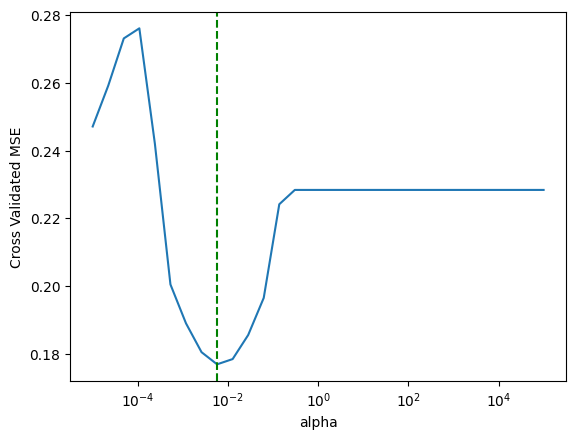

In [15]:
sns.lineplot( x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

5. Plot the coefficient paths by $\alpha$.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1349485219511024, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.012170379528015474, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4.892157344158775, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: C

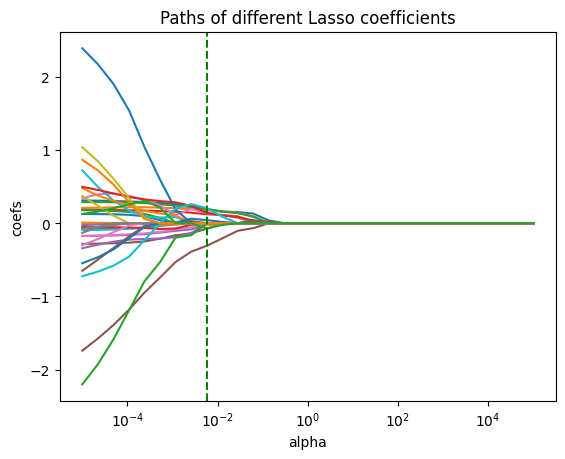

In [16]:
results = lasso_path(x, y, alphas=alpha_grid)

alphas_path = results[0]
coefs = results[1]
extra_info = results[2]

for coef in coefs:
    plt.plot(alphas_path, coef)
plt.axvline(x=model.alpha_, color='green', linestyle='--')
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefs")
plt.title("Paths of different Lasso coefficients")
plt.show()

6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [17]:
coef_table = pd.DataFrame({
    'feature': x.columns,
    'LASSO coefficient': model.coef_,
    'linear regression coefficient': lr.coef_
})

coef_table

,feature,LASSO coefficient,linear regression coefficient
0,anaemia,0.014177,-0.043420
1,diabetes,0.000609,-0.149472
2,high_blood_pressure,0.013609,-0.073480
3,smoking,-0.000000,-0.168209
4,anaemia diabetes,0.000000,0.137585
5,anaemia high_blood_pressure,0.000000,0.040708
6,anaemia smoking,0.000000,0.139289
7,diabetes high_blood_pressure,0.053965,0.282831
8,diabetes smoking,0.003466,0.337922
9,high_blood_pressure smoking,0.017803,0.213817


In [18]:
print (np.where(model.coef_ != 0)[0])
print (len(np.where(model.coef_ != 0)[0])/len(x.columns))

[ 0  1  2  7  8  9 15 16 23 29 30 32]
0.36363636363636365


The selected features are the non-zero ones above, with 36% (12/33) being set to 0. The anemia, diabetes, and high blood pressure coeffs become positive, which makes sense as most of their interactions, which were previously positive, are dropped. The ejection_fraction^3 one becomes positive too. Coeffs generally become smaller in magnitude, which makes sense according to the bias-variance trade-off: as we get a less fitted model, we have less variance overall with smaller coeffs.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

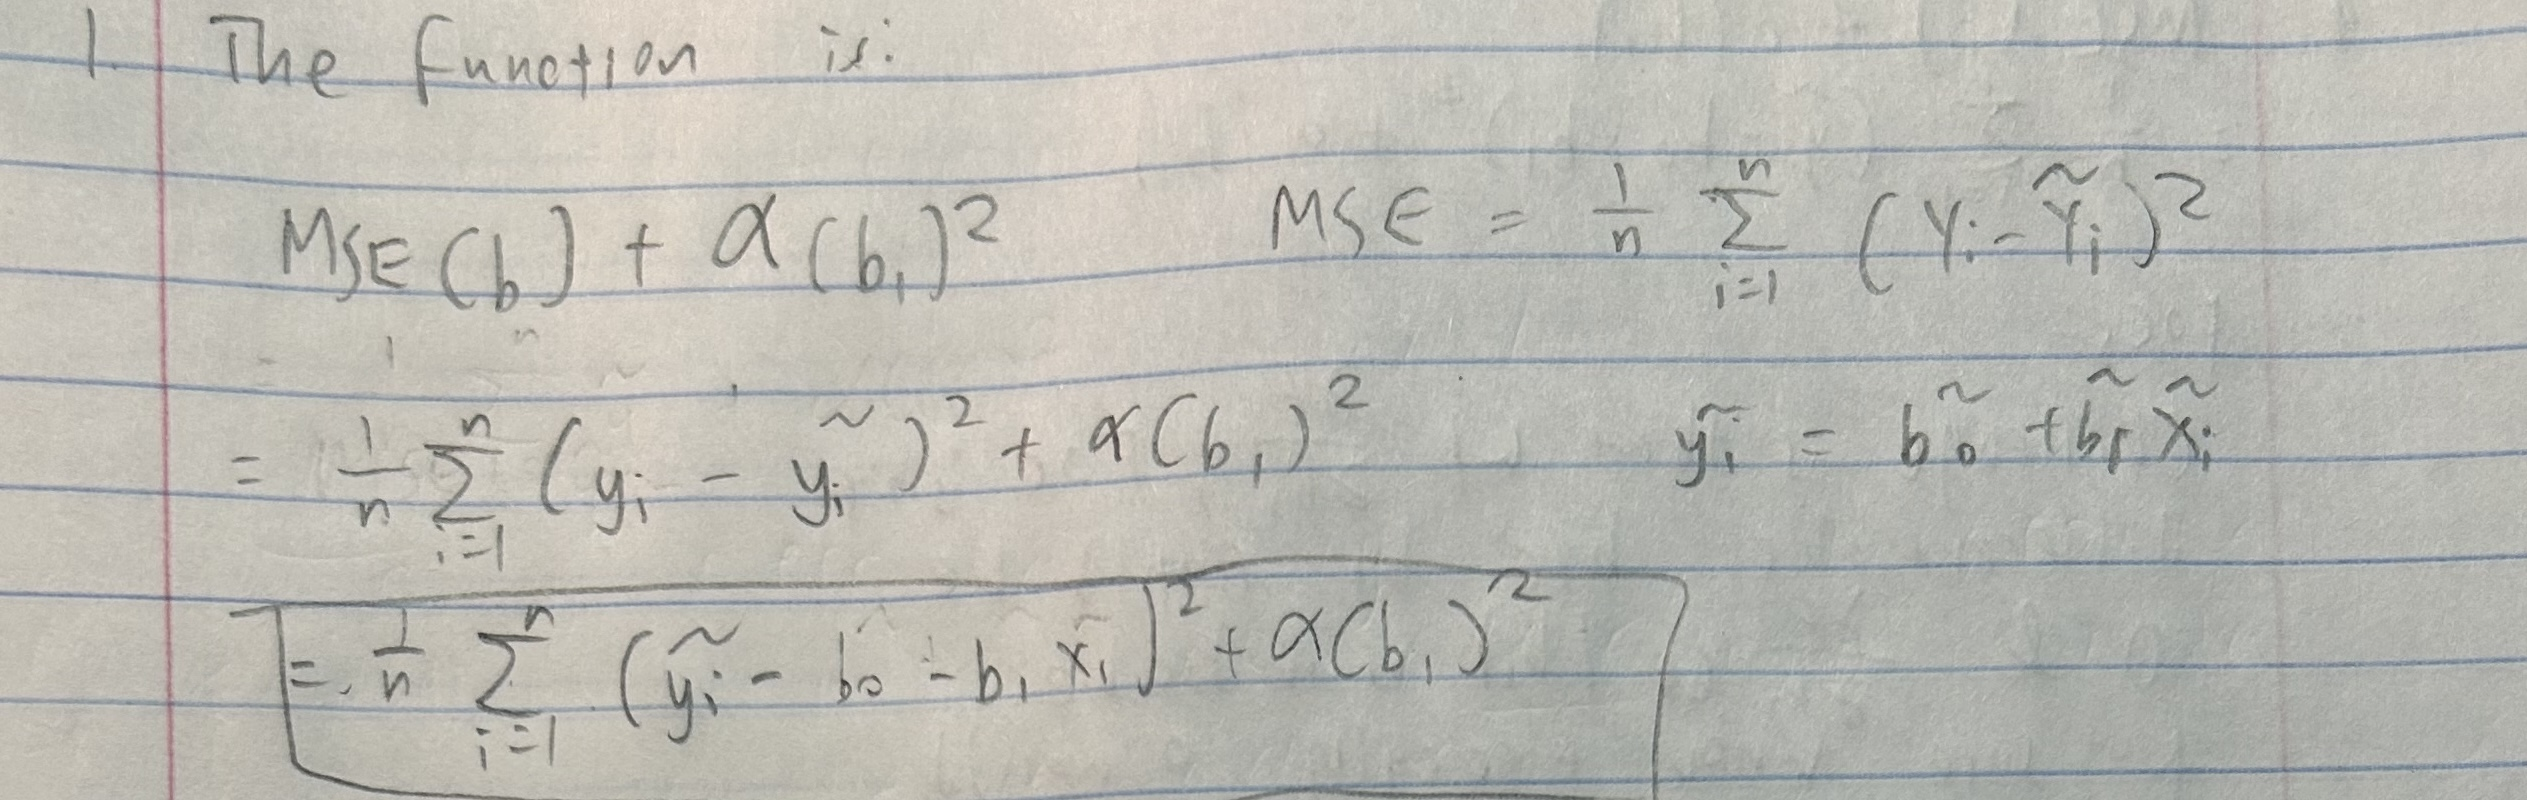

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

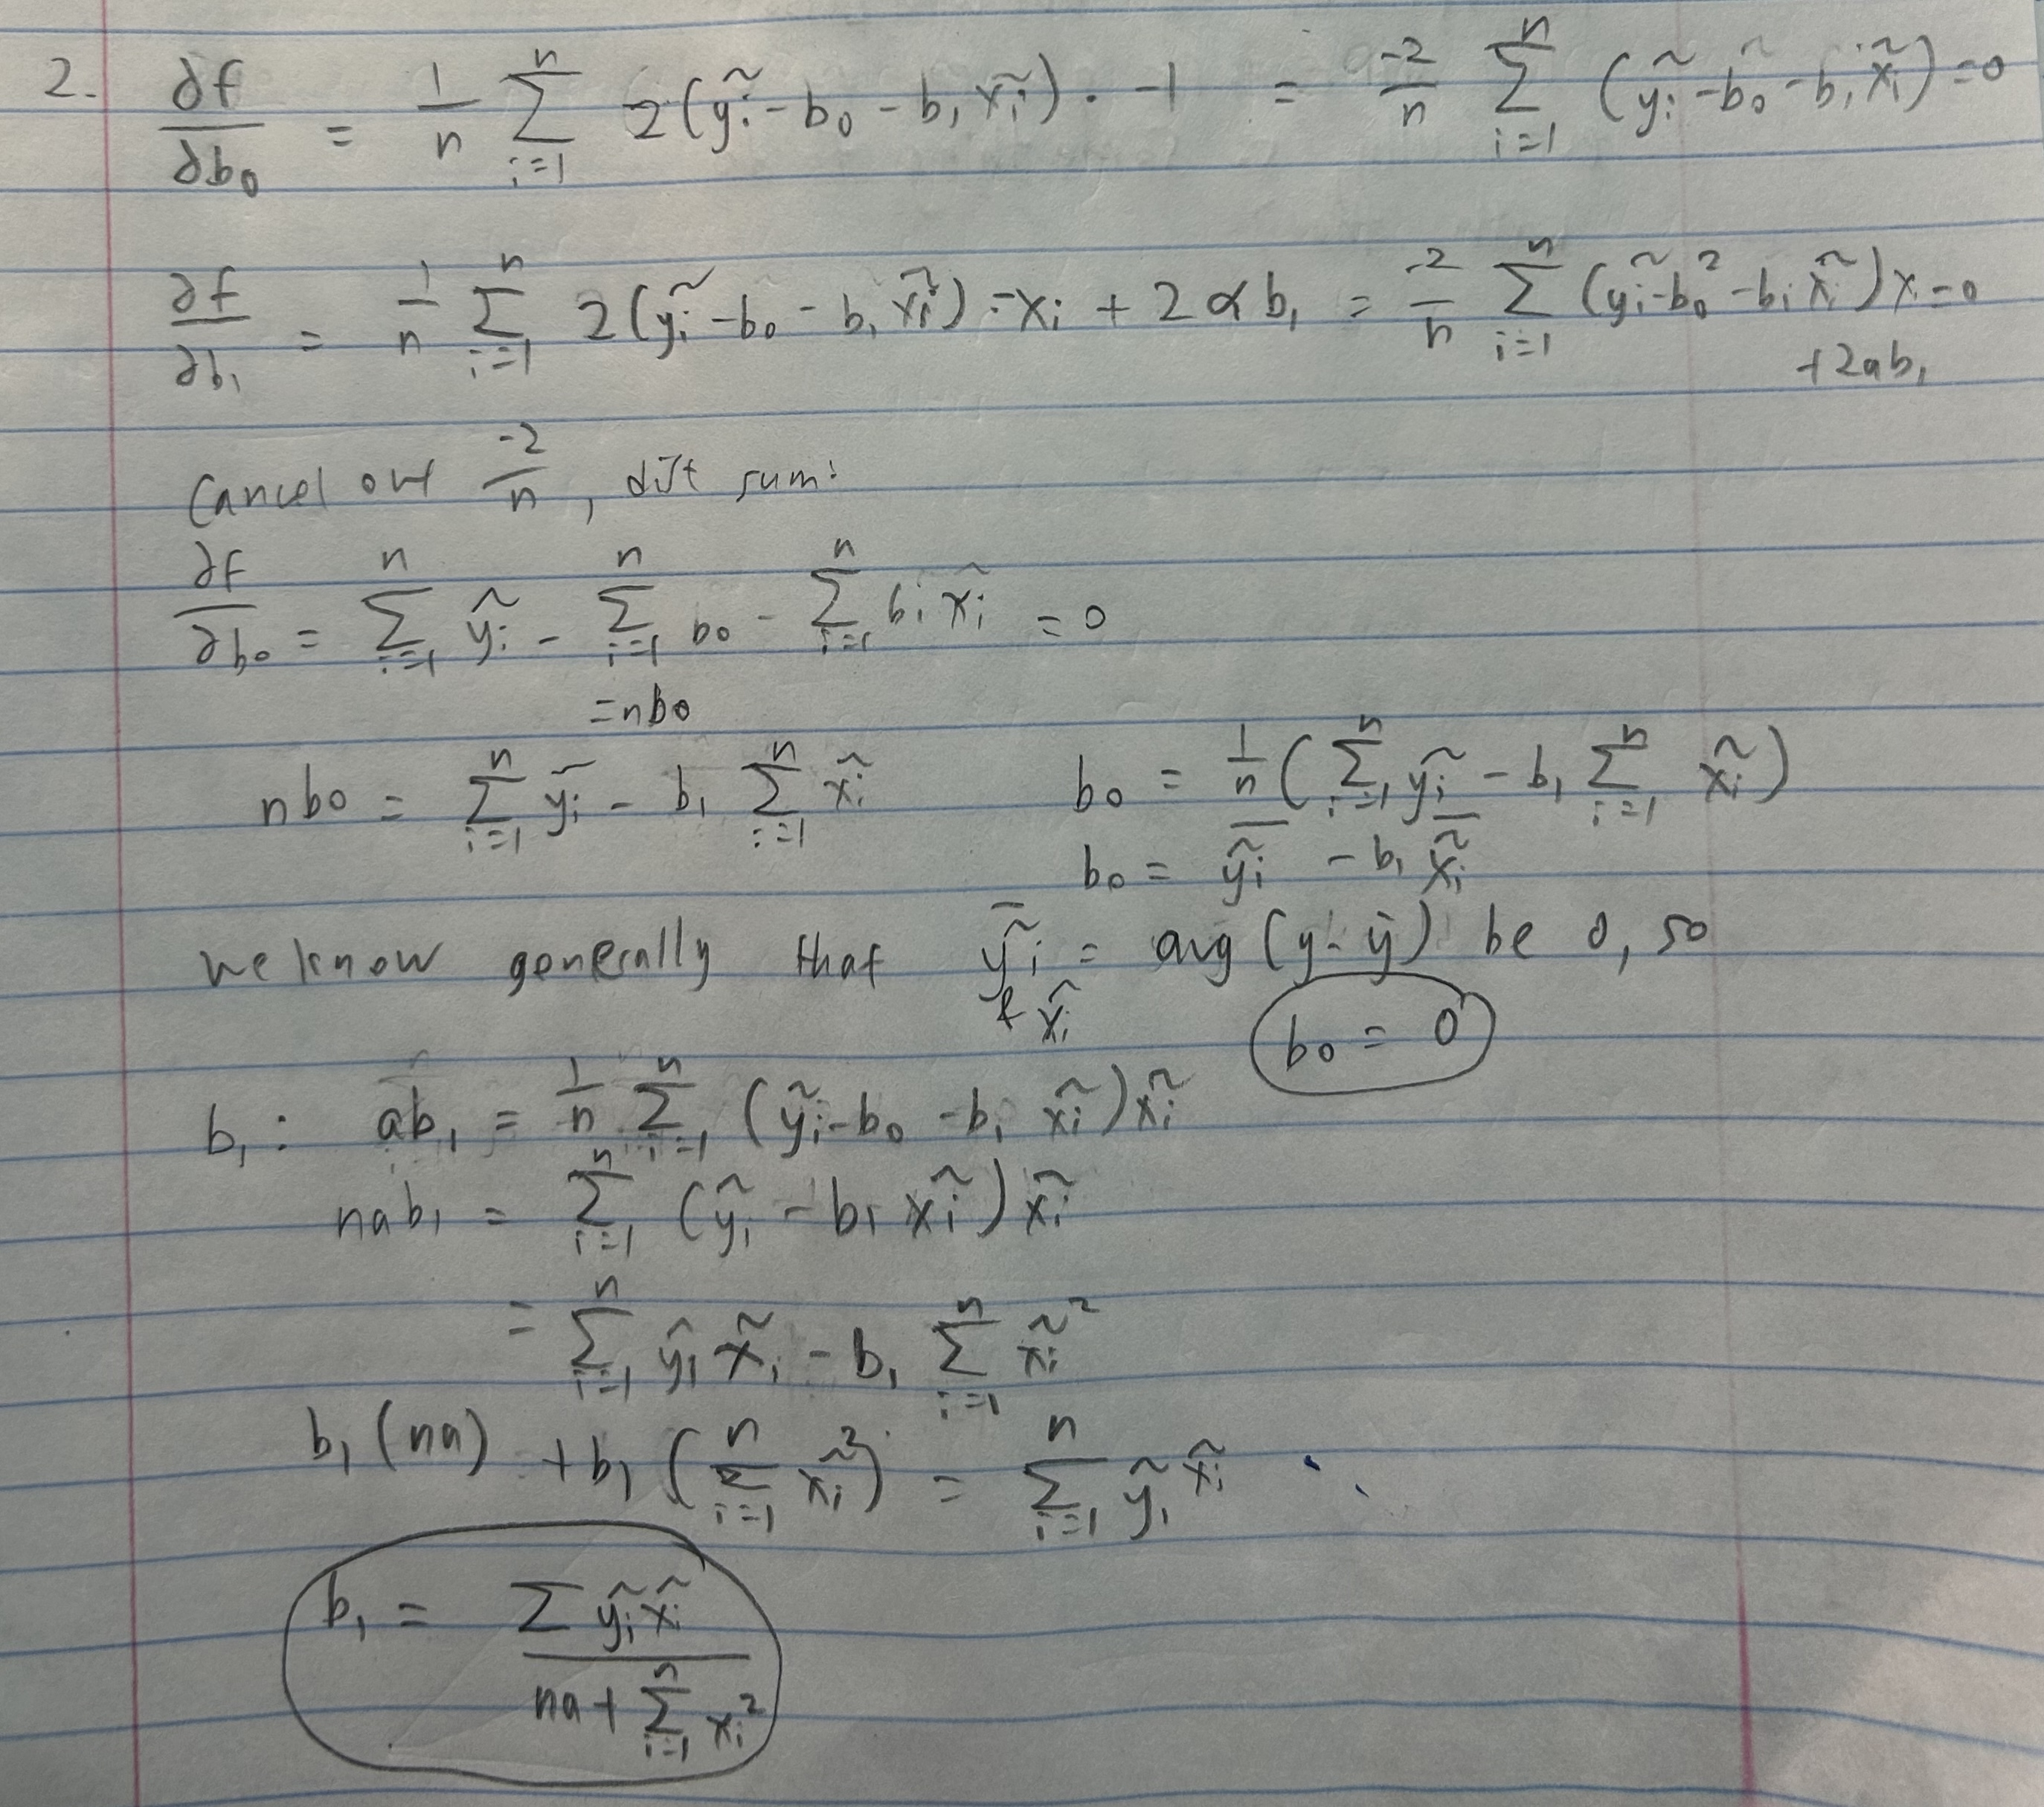

3. How does increasing $\alpha$ change the slope coefficient?

Increasing $\alpha$ makes the slope coefficient decrease, as $\alpha$ is solely on the denominator.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

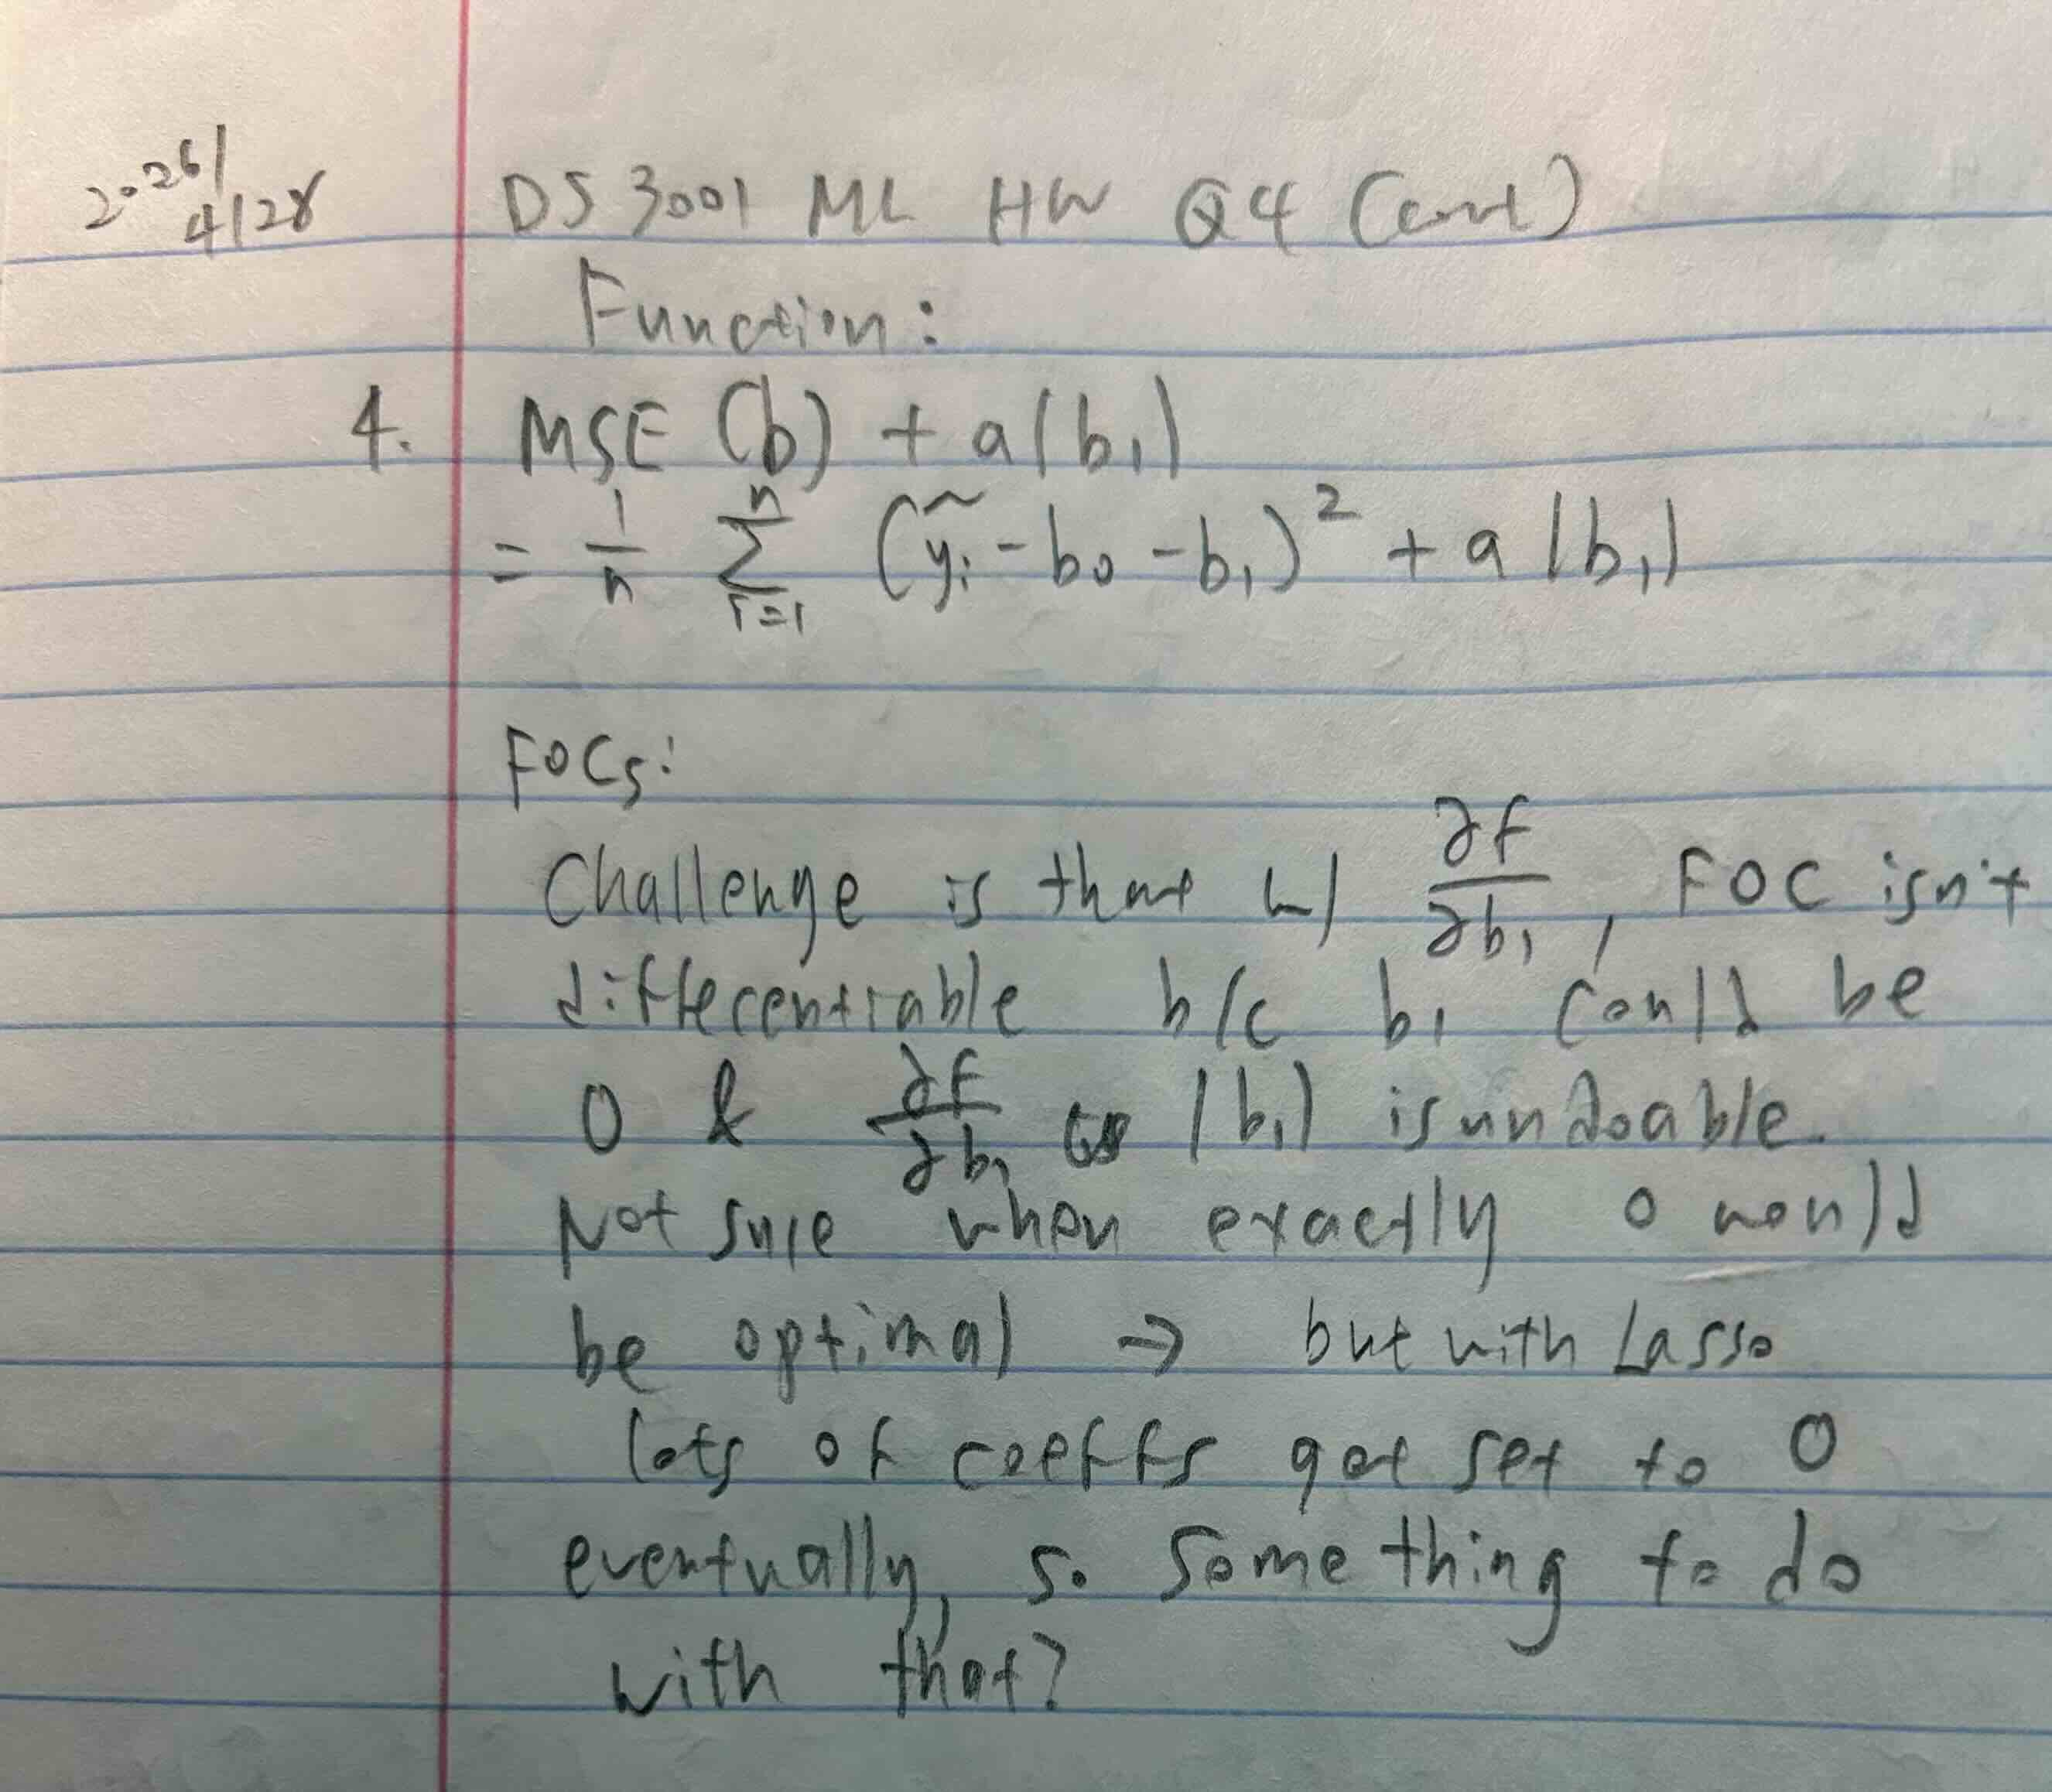